# Entrega H1 — Proyecto RecSys
## Tema: Multimodalidad: Recomendación de Videojuegos


**Dataset:** [Game Recommendations on Steam](https://www.kaggle.com/datasets/antonkozyriev/game-recommendations-on-steam) — ~41M interacciones, ~37K juegos, ~14M usuarios.

Se decidió descartar el dataset entregado en el Excel de proyectos disponibles debido a que no contaba con datos específicos para cada usuario, lo cual es imprescindible para este proyecto.

**Señal de preferencia:** Se utilizan ambas señales disponibles: `is_recommended` (binaria, define si una interacción es positiva) y `hours` (continua, se usa como peso de confianza mediante `log1p(hours)`). Las interacciones negativas (`is_recommended=False`) se mantienen en el historial para evitar re-recomendar, pero no se usan como señal positiva de entrenamiento.

## 0. Configuración e importaciones

In [ ]:
!pip install -q kagglehub implicit

import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
import scipy.sparse as sp
import implicit
from scipy.sparse import csr_matrix

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

import kagglehub
PATH = kagglehub.dataset_download("antonkozyriev/game-recommendations-on-steam")
print("Dataset en:", PATH)
print("Archivos:", os.listdir(PATH))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 1.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


100%|██████████| 660M/660M [00:08<00:00, 83.8MB/s]

Extracting files...


Dataset en: /root/.cache/kagglehub/datasets/antonkozyriev/game-recommendations-on-steam/versions/28
Archivos: ['games_metadata.json', 'recommendations.csv', 'games.csv', 'users.csv']


## 1. Análisis de `games.csv`

Este archivo contiene metadatos agregados de cada juego en Steam. Las variables clave para el sistema recomendador son: `positive_ratio` (calidad percibida), `user_reviews` (popularidad), `price_final` (accesibilidad) y `date_release` (posibles sesgos temporales).

**Importante:** `user_reviews` aquí es un conteo agregado de Steam, **no** equivale al número de interacciones observables en `recommendations.csv`. Son conceptualmente distintas.

In [ ]:
games = pd.read_csv(os.path.join(PATH, "games.csv"))
users = pd.read_csv(os.path.join(PATH, "users.csv"))

print(f"games:  {games.shape[0]:,} filas x {games.shape[1]} columnas")
print(f"users:  {users.shape[0]:,} filas x {users.shape[1]} columnas\n")

info_g = pd.DataFrame({
    'dtype':   games.dtypes,
    'nulos':   games.isnull().sum(),
    '%nulos':  (games.isnull().mean()*100).round(1),
    'únicos':  games.nunique()
})
display(info_g)
display(games.describe().round(2))

games:  50,872 filas x 13 columnas
users:  14,306,064 filas x 3 columnas



,dtype,nulos,%nulos,únicos
app_id,int64,0,0.0,50872
title,object,0,0.0,50751
date_release,object,0,0.0,4292
win,bool,0,0.0,2
mac,bool,0,0.0,2
linux,bool,0,0.0,2
rating,object,0,0.0,9
positive_ratio,int64,0,0.0,100
user_reviews,int64,0,0.0,4847
price_final,float64,0,0.0,436


,app_id,positive_ratio,user_reviews,price_final,price_original,discount
count,50872.00,50872.00,50872.00,50872.00,50872.00,50872.00
mean,1055223.81,77.05,1824.42,8.62,8.73,5.59
std,610324.95,18.25,40073.52,11.51,11.51,18.61
min,10.00,0.00,10.00,0.00,0.00,0.00
25%,528737.50,67.00,19.00,0.99,0.99,0.00
50%,986085.00,81.00,49.00,4.99,4.99,0.00
75%,1524895.00,91.00,206.00,10.99,11.99,0.00
max,2599300.00,100.00,7494460.00,299.99,299.99,90.00


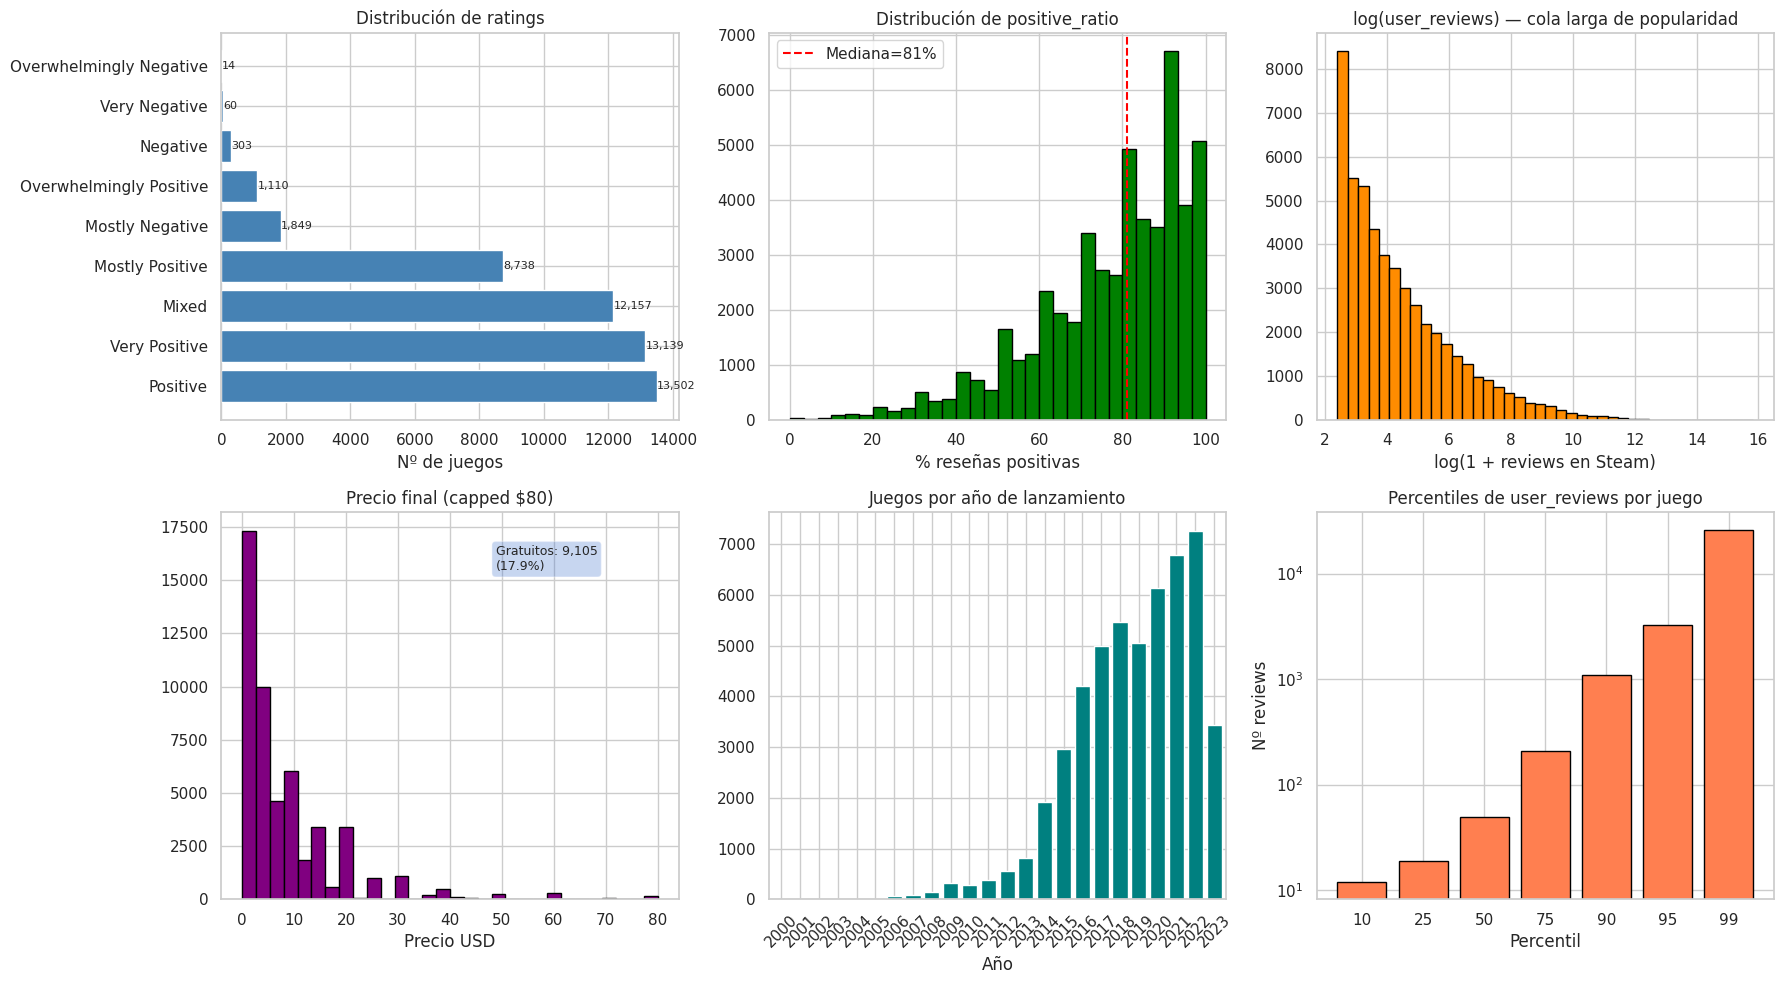

Precio mediano: $4.99
Juegos gratuitos: 9,105 (17.9%)
Año de lanzamiento: 1997 – 2023
Mediana user_reviews: 49
p99 user_reviews: 26,065
Máximo user_reviews: 7,494,460


In [ ]:
# Distribuciones clave de games.csv
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Categorías de rating
rating_counts = games['rating'].value_counts()
axes[0,0].barh(rating_counts.index, rating_counts.values, color='steelblue')
axes[0,0].set_title('Distribución de ratings')
axes[0,0].set_xlabel('Nº de juegos')
for bar, val in zip(axes[0,0].patches, rating_counts.values):
    axes[0,0].text(val + 10, bar.get_y() + bar.get_height()/2,
                   f'{val:,}', va='center', fontsize=8)

# 2. Positive ratio
games['positive_ratio'].dropna().hist(bins=30, ax=axes[0,1], color='green', edgecolor='black')
axes[0,1].set_title('Distribución de positive_ratio')
axes[0,1].set_xlabel('% reseñas positivas')
axes[0,1].axvline(games['positive_ratio'].median(), color='red', linestyle='--',
                   label=f"Mediana={games['positive_ratio'].median():.0f}%")
axes[0,1].legend()

# 3. user_reviews en escala log
games['user_reviews'].dropna().apply(np.log1p).hist(bins=40, ax=axes[0,2], color='darkorange', edgecolor='black')
axes[0,2].set_title('log(user_reviews) — cola larga de popularidad')
axes[0,2].set_xlabel('log(1 + reviews en Steam)')

# 4. Precio final
price_capped = games['price_final'].clip(0, 80).dropna()
price_capped.hist(bins=30, ax=axes[1,0], color='purple', edgecolor='black')
axes[1,0].set_title('Precio final (capped $80)')
axes[1,0].set_xlabel('Precio USD')
free_count = (games['price_final'] == 0).sum()
axes[1,0].text(0.6, 0.85, f'Gratuitos: {free_count:,}\n({free_count/len(games)*100:.1f}%)',
               transform=axes[1,0].transAxes, fontsize=9, bbox=dict(boxstyle='round', alpha=0.3))

# 5. Año de lanzamiento
games['year_release'] = pd.to_datetime(games['date_release'], errors='coerce').dt.year
year_counts = games['year_release'].dropna().astype(int).value_counts().sort_index()
year_counts = year_counts[year_counts.index >= 2000]
year_counts.plot(kind='bar', ax=axes[1,1], color='teal', width=0.8)
axes[1,1].set_title('Juegos por año de lanzamiento')
axes[1,1].set_xlabel('Año')
axes[1,1].tick_params(axis='x', rotation=45)

# 6. user_reviews percentiles (log scale)
pcts = [10, 25, 50, 75, 90, 95, 99]
vals = [games['user_reviews'].quantile(p/100) for p in pcts]
axes[1,2].bar([str(p) for p in pcts], vals, color='coral', edgecolor='black')
axes[1,2].set_title('Percentiles de user_reviews por juego')
axes[1,2].set_xlabel('Percentil')
axes[1,2].set_ylabel('Nº reviews')
axes[1,2].set_yscale('log')

plt.tight_layout()
plt.show()

print(f"Precio mediano: ${games['price_final'].median():.2f}")
print(f"Juegos gratuitos: {free_count:,} ({free_count/len(games)*100:.1f}%)")
print(f"Año de lanzamiento: {games['year_release'].min():.0f} – {games['year_release'].max():.0f}")
print(f"Mediana user_reviews: {games['user_reviews'].median():,.0f}")
print(f"p99 user_reviews: {games['user_reviews'].quantile(0.99):,.0f}")
print(f"Máximo user_reviews: {games['user_reviews'].max():,.0f}")

## 2. Análisis de `users.csv`

Cada usuario tiene dos métricas: `products` (juegos en su biblioteca) y `reviews` (reseñas publicadas). Para el recomendador, `reviews` es la señal observable — solo los usuarios con reviews aparecerán en `recommendations.csv`. La diferencia entre ambas variables informa sobre el nivel de "participación activa" de los usuarios.

,dtype,nulos,únicos
user_id,int64,0,14306064
products,int64,0,7572
reviews,int64,0,681


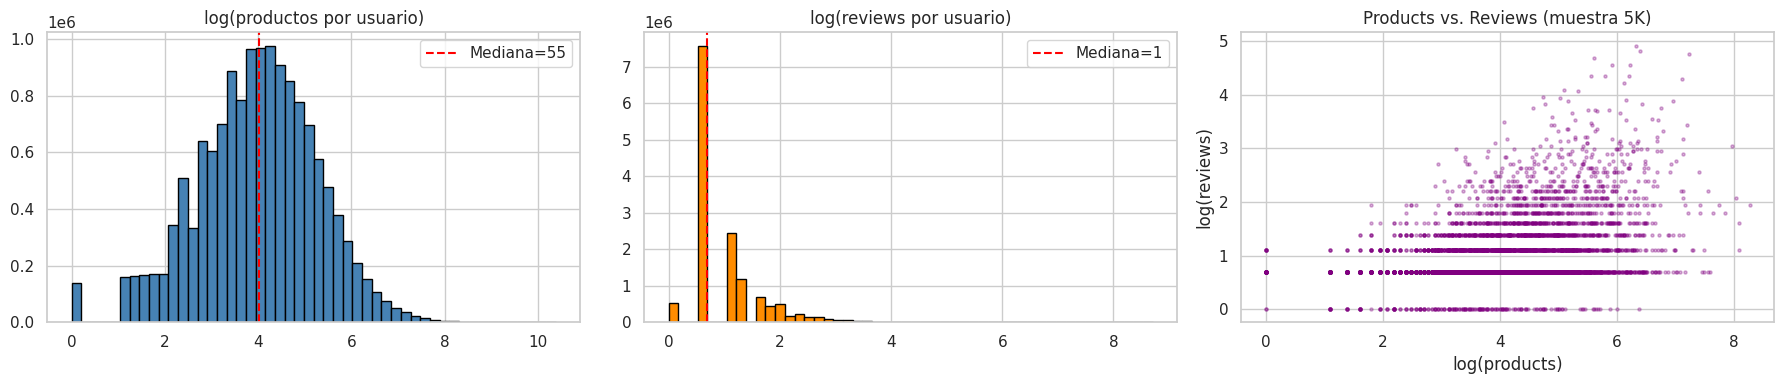

Total usuarios: 14,306,064
% con 0 reviews: 3.7%
% con 1+ reviews: 96.3%
Mediana products: 55 | p95: 401
Mediana reviews:  1 | p95: 9


In [ ]:
info_u = pd.DataFrame({
    'dtype': users.dtypes,
    'nulos': users.isnull().sum(),
    'únicos': users.nunique()
})
display(info_u)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. Distribución de products (log)
users['products'].apply(np.log1p).hist(bins=50, ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('log(productos por usuario)')
axes[0].axvline(np.log1p(users['products'].median()), color='red', linestyle='--',
                label=f"Mediana={users['products'].median():.0f}")
axes[0].legend()

# 2. Distribución de reviews (log)
users['reviews'].apply(np.log1p).hist(bins=50, ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('log(reviews por usuario)')
axes[1].axvline(np.log1p(users['reviews'].median()), color='red', linestyle='--',
                label=f"Mediana={users['reviews'].median():.0f}")
axes[1].legend()

# 3. Scatter products vs reviews (muestra para visualización)
sample_u = users.sample(min(5000, len(users)), random_state=42)
axes[2].scatter(np.log1p(sample_u['products']), np.log1p(sample_u['reviews']),
                alpha=0.3, s=5, color='purple')
axes[2].set_xlabel('log(products)')
axes[2].set_ylabel('log(reviews)')
axes[2].set_title('Products vs. Reviews (muestra 5K)')

plt.tight_layout()
plt.show()

print(f"Total usuarios: {len(users):,}")
print(f"% con 0 reviews: {(users['reviews']==0).mean()*100:.1f}%")
print(f"% con 1+ reviews: {(users['reviews']>=1).mean()*100:.1f}%")
print(f"Mediana products: {users['products'].median():.0f} | p95: {users['products'].quantile(0.95):.0f}")
print(f"Mediana reviews:  {users['reviews'].median():.0f} | p95: {users['reviews'].quantile(0.95):.0f}")

## 3. `recommendations.csv` — Inspección estructural

Se leen las primeras 500K filas únicamente para inspeccionar estructura y tipos. Esta muestra es secuencial (no aleatoria), por lo que sus distribuciones no son representativas del dataset completo — como evidencia el número de juegos únicos observados. Los análisis de distribución se realizarán sobre el dataset completo en la sección siguiente.

In [ ]:
recs_sample = pd.read_csv(
    os.path.join(PATH, "recommendations.csv"),
    nrows=500_000,
    parse_dates=['date']
)

print("Muestra SECUENCIAL — solo para inspección de estructura")
print(f"Juegos únicos en muestra:   {recs_sample['app_id'].nunique():,}")
print(f"(vs ~37K en dataset completo — evidencia del sesgo secuencial)\n")

info_r = pd.DataFrame({
    'dtype':   recs_sample.dtypes,
    'nulos':   recs_sample.isnull().sum(),
    '%nulos':  (recs_sample.isnull().mean()*100).round(1),
    'únicos':  recs_sample.nunique()
})
display(info_r)
display(recs_sample.head(5))

total_rows = sum(1 for _ in open(os.path.join(PATH, "recommendations.csv"))) - 1
print(f"\nTotal de interacciones (conteo exacto): {total_rows:,}")

Muestra SECUENCIAL — solo para inspección de estructura
Juegos únicos en muestra:   213
(vs ~37K en dataset completo — evidencia del sesgo secuencial)



,dtype,nulos,%nulos,únicos
app_id,int64,0,0.0,213
helpful,int64,0,0.0,884
funny,int64,0,0.0,542
date,datetime64[ns],0,0.0,3855
is_recommended,bool,0,0.0,2
hours,float64,0,0.0,10000
user_id,int64,0,0.0,472424
review_id,int64,0,0.0,500000


,app_id,helpful,funny,date,is_recommended,hours,user_id,review_id
0,975370,0,0,2022-12-12,True,36.3,51580,0
1,304390,4,0,2017-02-17,False,11.5,2586,1
2,1085660,2,0,2019-11-17,True,336.5,253880,2
3,703080,0,0,2022-09-23,True,27.4,259432,3
4,526870,0,0,2021-01-10,True,7.9,23869,4



Total de interacciones (conteo exacto): 41,154,794


## 4. Carga completa de `recommendations.csv`

Se carga el dataset completo (~41M filas) en chunks usando tipos de dato optimizados para reducir el consumo de memoria.

In [ ]:
print("Cargando recommendations.csv completo en chunks...")

chunks = []
for chunk in pd.read_csv(
    os.path.join(PATH, "recommendations.csv"),
    chunksize=1_000_000,
    parse_dates=['date'],
    dtype={
        'app_id':         'int32',
        'user_id':        'int32',
        'hours':          'float32',
        'is_recommended': 'bool',
        'helpful':        'int16',
        'funny':          'int16'
    }
):
    chunks.append(chunk)

recs_full = pd.concat(chunks, ignore_index=True)
mem_gb = recs_full.memory_usage(deep=True).sum() / 1e9
print(f"Total cargado: {len(recs_full):,} filas")
print(f"Memoria usada: {mem_gb:.2f} GB")
display(recs_full.dtypes)

Cargando recommendations.csv completo en chunks...
Total cargado: 41,154,794 filas
Memoria usada: 1.36 GB


,0
app_id,int32
helpful,int16
funny,int16
date,datetime64[ns]
is_recommended,bool
hours,float32
user_id,int32
review_id,int64


## 5. Análisis de interacciones (dataset completo)

### 5.1 Verificación de duplicados por par (user_id, app_id)

En una matriz usuario-ítem se necesita exactamente una observación por par. Se verifica si existen múltiples reviews del mismo usuario para el mismo juego.

In [ ]:
n_total = len(recs_full)
n_unique_pairs = recs_full[['user_id', 'app_id']].drop_duplicates().shape[0]
n_duplicates = n_total - n_unique_pairs

print(f"Total filas:                 {n_total:,}")
print(f"Pares únicos (user, juego):  {n_unique_pairs:,}")
print(f"Filas duplicadas:            {n_duplicates:,} ({n_duplicates/n_total*100:.3f}%)")

if n_duplicates > 0:
    # Inspeccionar algunos duplicados
    dup_pairs = recs_full[recs_full.duplicated(subset=['user_id','app_id'], keep=False)]
    print(f"\nEjemplo de pares duplicados:")
    display(dup_pairs.sort_values(['user_id','app_id']).head(8))

    # Estrategia: para cada par (user_id, app_id), conservar la interacción más reciente
    recs_full = recs_full.sort_values('date').drop_duplicates(
        subset=['user_id', 'app_id'], keep='last'
    ).reset_index(drop=True)
    print(f"\nDespués de deduplicación: {len(recs_full):,} filas")
else:
    print("\n✓ No hay duplicados — cada par (user_id, app_id) es único.")

Total filas:                 41,154,794
Pares únicos (user, juego):  41,154,773
Filas duplicadas:            21 (0.000%)

Ejemplo de pares duplicados:


,app_id,helpful,funny,date,is_recommended,hours,user_id,review_id
36533636,1205960,0,0,2021-12-04,False,3.000000,1085990,36533636
38113748,1205960,0,0,2021-12-03,True,3.000000,1085990,38113748
24170089,440,0,0,2021-12-02,True,658.000000,2433696,24170089
24887439,440,0,0,2021-12-04,True,658.000000,2433696,24887439
15321463,1454400,0,0,2021-12-07,True,21.400000,3054178,15321463
23765890,1454400,0,0,2021-12-03,True,21.400000,3054178,23765890
25753093,1118200,0,0,2022-06-12,True,53.200001,3070422,25753093
26644717,1118200,0,0,2022-06-07,True,53.200001,3070422,26644717



Después de deduplicación: 41,154,773 filas


### 5.2 Distribución de `is_recommended` y `hours`

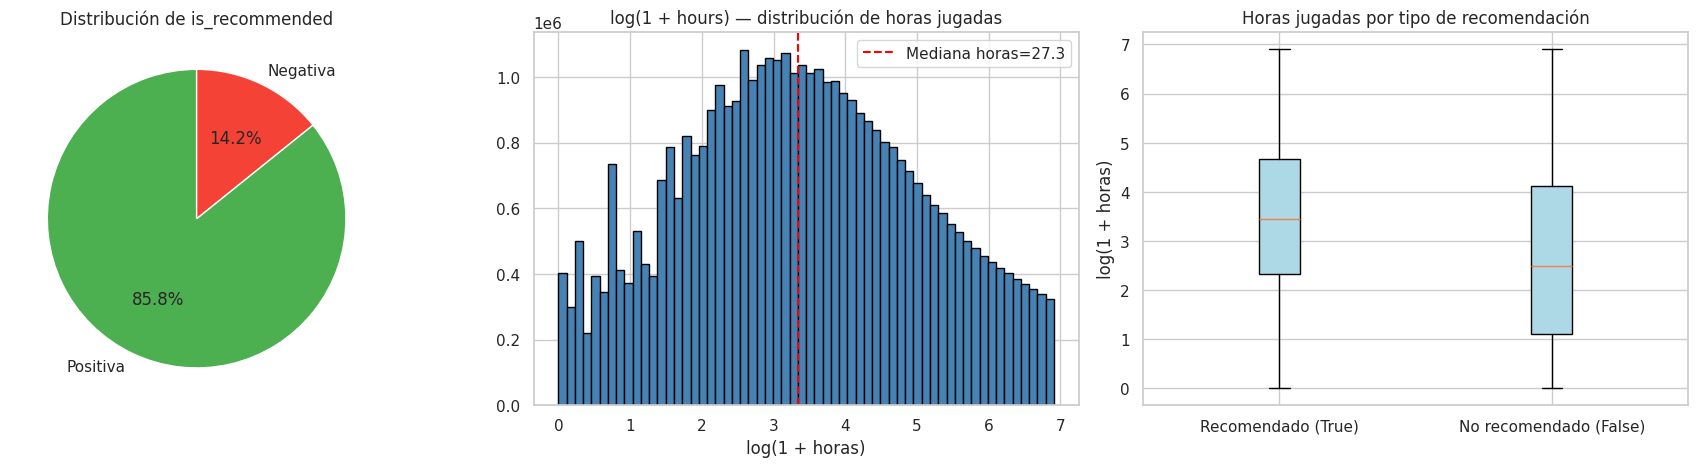

% interacciones positivas:   85.8%
% interacciones negativas:   14.2%

Distribución de hours:
count    41154773.00
mean          100.60
std           165.64
min             0.00
25%             7.80
50%            27.30
75%            99.20
max          1000.00

Mediana horas (positivas):   30.3
Mediana horas (negativas):   11.1

p99 de horas: 864.5 | Máximo observado: 1000.0
El máximo sugiere posible truncamiento/cap en el dataset (top-coding).


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. is_recommended
rec_counts = recs_full['is_recommended'].value_counts()
axes[0].pie(rec_counts.values, labels=['Positiva', 'Negativa'],
            autopct='%1.1f%%', colors=['#4CAF50','#F44336'], startangle=90)
axes[0].set_title('Distribución de is_recommended')

# 2. Distribución de horas (escala log)
hours_log = np.log1p(recs_full['hours'])
hours_log.hist(bins=60, ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('log(1 + hours) — distribución de horas jugadas')
axes[1].set_xlabel('log(1 + horas)')
axes[1].axvline(hours_log.median(), color='red', linestyle='--',
                label=f"Mediana horas={recs_full['hours'].median():.1f}")
axes[1].legend()

# 3. Horas jugadas por categoría de recomendación
rec_true  = recs_full[recs_full['is_recommended']]['hours'].clip(0, 1000)
rec_false = recs_full[~recs_full['is_recommended']]['hours'].clip(0, 1000)
axes[2].boxplot([np.log1p(rec_true), np.log1p(rec_false)],
                labels=['Recomendado (True)', 'No recomendado (False)'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[2].set_title('Horas jugadas por tipo de recomendación')
axes[2].set_ylabel('log(1 + horas)')

plt.tight_layout()
plt.show()

pos_rate = recs_full['is_recommended'].mean()
print(f"% interacciones positivas:   {pos_rate*100:.1f}%")
print(f"% interacciones negativas:   {(1-pos_rate)*100:.1f}%")
print(f"\nDistribución de hours:")
print(recs_full['hours'].describe().round(2).to_string())
print(f"\nMediana horas (positivas):   {recs_full[recs_full['is_recommended']]['hours'].median():.1f}")
print(f"Mediana horas (negativas):   {recs_full[~recs_full['is_recommended']]['hours'].median():.1f}")

cap_99 = recs_full['hours'].quantile(0.99)
cap_max = recs_full['hours'].max()
print(f"\np99 de horas: {cap_99:.1f} | Máximo observado: {cap_max:.1f}")
if cap_max <= 1000:
    print("El máximo sugiere posible truncamiento/cap en el dataset (top-coding).")

### 5.3 Análisis temporal

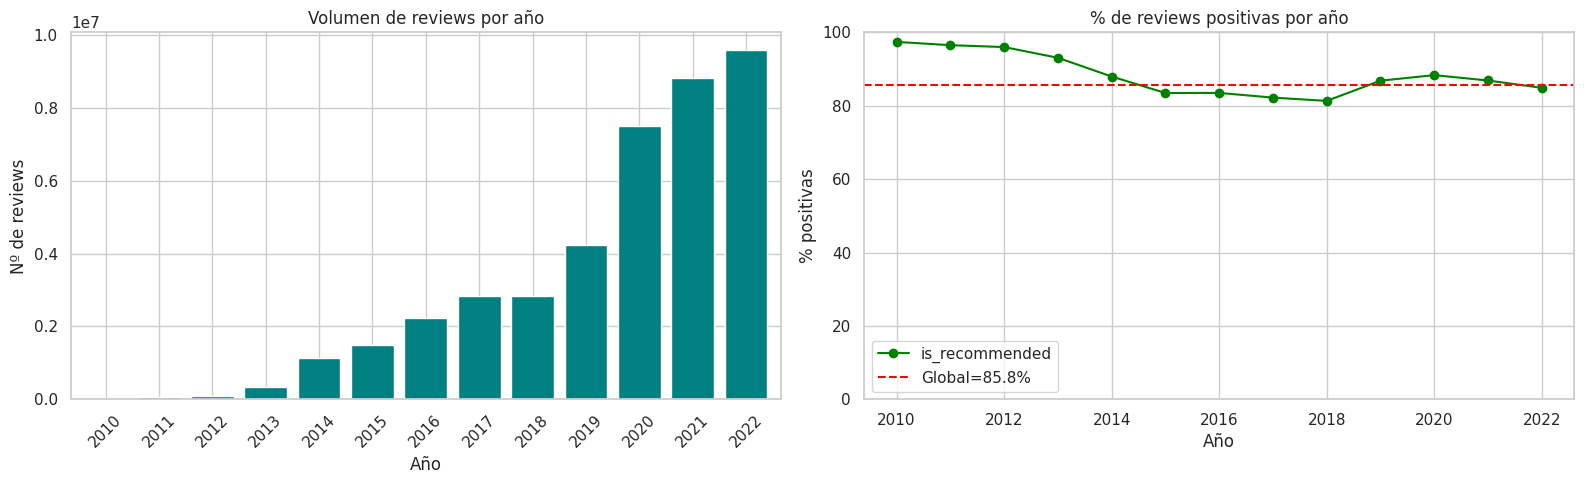

Rango temporal: 2010-10-15 — 2022-12-31

Volumen por año:
  2010:       12,201 reviews
  2011:       71,546 reviews
  2012:      101,726 reviews
  2013:      335,335 reviews
  2014:    1,143,155 reviews
  2015:    1,477,096 reviews
  2016:    2,226,413 reviews
  2017:    2,834,442 reviews
  2018:    2,845,219 reviews
  2019:    4,226,832 reviews
  2020:    7,488,439 reviews
  2021:    8,802,848 reviews
  2022:    9,589,521 reviews


In [ ]:
recs_full['year'] = recs_full['date'].dt.year

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Volumen de reviews por año
year_counts = recs_full['year'].value_counts().sort_index()
year_counts.plot(kind='bar', ax=axes[0], color='teal', width=0.8)
axes[0].set_title('Volumen de reviews por año')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Nº de reviews')
axes[0].tick_params(axis='x', rotation=45)

# 2. % positivas por año
pos_by_year = recs_full.groupby('year')['is_recommended'].mean() * 100
pos_by_year.plot(kind='line', ax=axes[1], color='green', marker='o')
axes[1].set_title('% de reviews positivas por año')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('% positivas')
axes[1].set_ylim(0, 100)
axes[1].axhline(pos_rate*100, color='red', linestyle='--', label=f'Global={pos_rate*100:.1f}%')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Rango temporal: {recs_full['date'].min().date()} — {recs_full['date'].max().date()}")
print(f"\nVolumen por año:")
for yr, cnt in year_counts.items():
    print(f"  {yr}: {cnt:>12,} reviews")

### 5.4 Actividad por usuario y juego

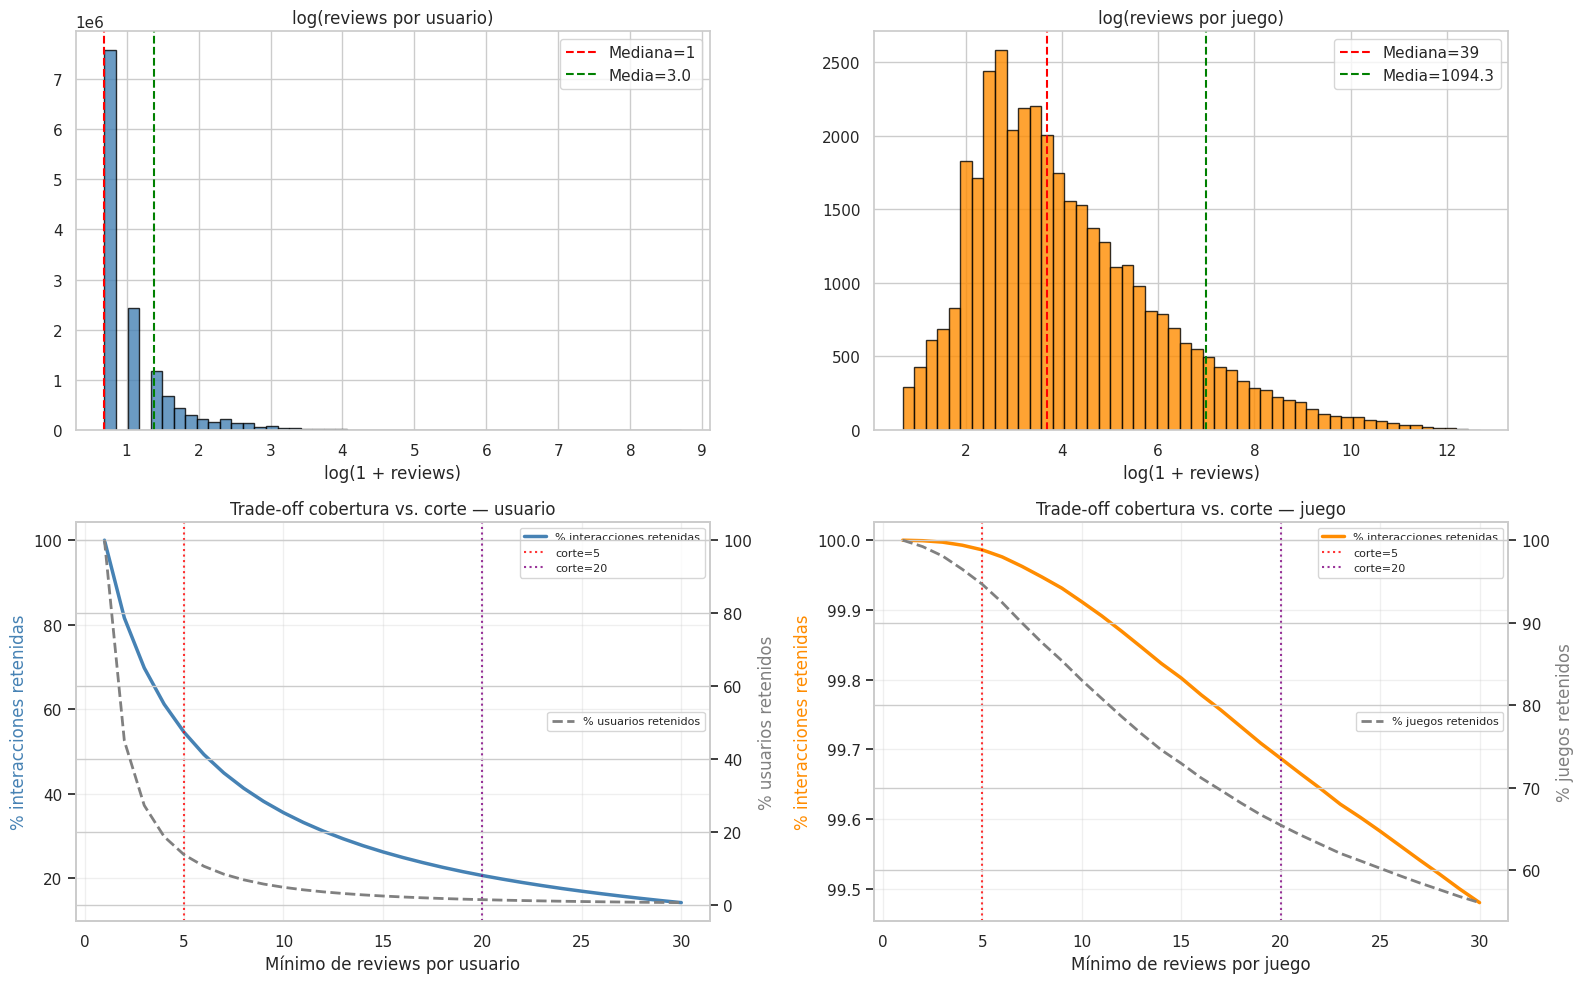

 Corte |  Usuarios ret. |   % usrs |  Juegos ret. |   % juegos
------------------------------------------------------------
     1 |     13,781,059 |   100.0% |       37,610 |     100.0%
     5 |      1,910,830 |    13.9% |       35,598 |      94.7%
    10 |        680,809 |     4.9% |       31,226 |      83.0%
    20 |        213,362 |     1.5% |       24,617 |      65.5%
    50 |         37,160 |     0.3% |       16,977 |      45.1%


In [ ]:
user_counts_full = recs_full['user_id'].value_counts()
game_counts_full = recs_full['app_id'].value_counts()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, series, label, color in [
    (axes[0,0], user_counts_full, 'Usuarios', 'steelblue'),
    (axes[0,1], game_counts_full, 'Juegos',   'darkorange'),
]:
    series.apply(np.log1p).hist(bins=50, ax=ax, color=color, edgecolor='black', alpha=0.8)
    ax.axvline(np.log1p(series.median()), color='red',   linestyle='--', label=f'Mediana={series.median():.0f}')
    ax.axvline(np.log1p(series.mean()),   color='green', linestyle='--', label=f'Media={series.mean():.1f}')
    ax.set_title(f'log(reviews por {label[:-1].lower()})')
    ax.set_xlabel('log(1 + reviews)')
    ax.legend()

for ax, series, label, color in [
    (axes[1,0], user_counts_full, 'usuario', 'steelblue'),
    (axes[1,1], game_counts_full, 'juego',   'darkorange'),
]:
    cutoffs = list(range(1, 31))
    total_int = series.sum()
    total_ent = len(series)
    coverage   = [series[series >= c].sum()  / total_int * 100 for c in cutoffs]
    entity_pct = [(series >= c).sum() / total_ent * 100          for c in cutoffs]

    ax2 = ax.twinx()
    ax.plot(cutoffs, coverage,    color=color,  linewidth=2.5, label='% interacciones retenidas')
    ax2.plot(cutoffs, entity_pct, color='gray', linewidth=2, linestyle='--', label=f'% {label}s retenidos')
    ax.axvline(x=5,  color='red',    linestyle=':', alpha=0.8, label='corte=5')
    ax.axvline(x=20, color='purple', linestyle=':', alpha=0.8, label='corte=20')
    ax.set_xlabel(f'Mínimo de reviews por {label}')
    ax.set_ylabel('% interacciones retenidas', color=color)
    ax2.set_ylabel(f'% {label}s retenidos', color='gray')
    ax.set_title(f'Trade-off cobertura vs. corte — {label}')
    ax.legend(loc='upper right', fontsize=8)
    ax2.legend(loc='center right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"{'Corte':>6} | {'Usuarios ret.':>14} | {'% usrs':>8} | {'Juegos ret.':>12} | {'% juegos':>10}")
print("-" * 60)
for c in [1, 5, 10, 20, 50]:
    u = (user_counts_full >= c).sum()
    g = (game_counts_full >= c).sum()
    print(f"{c:>6} | {u:>14,} | {u/len(user_counts_full)*100:>7.1f}% | {g:>12,} | {g/len(game_counts_full)*100:>9.1f}%")

## 6. Filtrado k-core iterativo

Se aplica filtrado iterativo para obtener una submatriz estable donde todos los usuarios y juegos cumplan un mínimo de interacciones. Se usa filtrado iterativo porque eliminar entidades en una sola pasada puede dejar otras entidades por debajo del umbral.

**Cortes elegidos:**
- `MIN_USER_REVIEWS` = 5: permite separar interacciones para train/test por usuario. Con mediana de 1 review por usuario en el dataset completo, este corte restringe el problema a usuarios relativamente activos.
- `MIN_GAME_REVIEWS` = 20: la mediana de reviews por juego en el dataset completo es ~39, por lo que un corte de 20 no elimina la mayoría del catálogo. Se elige 20 (no 50) para conservar más del long-tail donde los metadatos multimodales pueden aportar mayor valor.

In [ ]:
MIN_USER_REVIEWS = 5
MIN_GAME_REVIEWS = 20

def iterative_k_core(df, min_user_reviews, min_game_reviews):
    df = df.copy()
    iteration = 0
    while True:
        n_before = len(df)
        user_counts = df['user_id'].value_counts()
        game_counts = df['app_id'].value_counts()
        valid_users = user_counts[user_counts >= min_user_reviews].index
        valid_games = game_counts[game_counts >= min_game_reviews].index
        df = df[df['user_id'].isin(valid_users) & df['app_id'].isin(valid_games)].copy()
        iteration += 1
        n_after = len(df)
        print(f"  Iter {iteration}: {n_before:,} -> {n_after:,} filas")
        if n_after == n_before:
            break
    return df

print(f"Aplicando k-core (min_user={MIN_USER_REVIEWS}, min_game={MIN_GAME_REVIEWS})...")
recs_filtered = iterative_k_core(recs_full, MIN_USER_REVIEWS, MIN_GAME_REVIEWS)

n_users_f = recs_filtered['user_id'].nunique()
n_items_f = recs_filtered['app_id'].nunique()
density    = len(recs_filtered) / (n_users_f * n_items_f) * 100

print(f"\n── Resultado del filtrado ──")
print(f"Interacciones: {len(recs_full):,} → {len(recs_filtered):,} ({len(recs_filtered)/len(recs_full)*100:.1f}% retenidas)")
print(f"Usuarios:      {recs_full['user_id'].nunique():,} -> {n_users_f:,}")
print(f"Juegos:        {recs_full['app_id'].nunique():,} -> {n_items_f:,}")
print(f"Densidad:      {density:.4f}%")
print(f"% positivas:   {recs_filtered['is_recommended'].mean()*100:.1f}%")

Aplicando k-core (min_user=5, min_game=20)...
  Iter 1: 41,154,773 -> 22,339,679 filas
  Iter 2: 22,339,679 -> 22,294,605 filas
  Iter 3: 22,294,605 -> 22,287,486 filas
  Iter 4: 22,287,486 -> 22,287,105 filas
  Iter 5: 22,287,105 -> 22,287,029 filas
  Iter 6: 22,287,029 -> 22,286,991 filas
  Iter 7: 22,286,991 -> 22,286,979 filas
  Iter 8: 22,286,979 -> 22,286,960 filas
  Iter 9: 22,286,960 -> 22,286,960 filas

── Resultado del filtrado ──
Interacciones: 41,154,773 → 22,286,960 (54.2% retenidas)
Usuarios:      13,781,059 -> 1,905,447
Juegos:        37,610 -> 22,676
Densidad:      0.0516%
% positivas:   84.8%


## 7. Análisis multimodal — `games_metadata.json`

Este archivo en formato **JSON Lines** (un objeto JSON por línea) contiene la información de contenido de los juegos: descripciones textuales y tags. Este es el núcleo de la modalidad de contenido del proyecto.

Los análisis buscan responder:
1. ¿Qué porcentaje de los juegos filtrados tienen metadata?
2. ¿Son los tags informativos y discriminativos?
3. ¿Las descripciones tienen calidad suficiente para embeddings?
4. ¿La metadata cubre mejor a los juegos populares o a los de nicho?

In [ ]:
# Carga del archivo JSONL completo
meta_records = []
with open(os.path.join(PATH, "games_metadata.json"), 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            try:
                meta_records.append(json.loads(line))
            except json.JSONDecodeError:
                pass

metadata = pd.DataFrame(meta_records)
print(f"Registros en metadata: {len(metadata):,}")
print(f"Columnas: {list(metadata.columns)}")
print(f"\nEjemplo de registro:")
print(json.dumps(meta_records[0], indent=2, ensure_ascii=False)[:600])

Registros en metadata: 50,872
Columnas: ['app_id', 'description', 'tags']

Ejemplo de registro:
{
  "app_id": 13500,
  "description": "Enter the dark underworld of Prince of Persia Warrior Within, the sword-slashing sequel to the critically acclaimed Prince of Persia: The Sands of Time™. Hunted by Dahaka, an immortal incarnation of Fate seeking divine retribution, the Prince embarks upon a path of both carnage and mystery to defy his preordained death.",
  "tags": [
    "Action",
    "Adventure",
    "Parkour",
    "Third Person",
    "Great Soundtrack",
    "Singleplayer",
    "Platformer",
    "Time Travel",
    "Atmospheric",
    "Classic",
    "Hack and Slash",
    "Time Manipulation


In [ ]:
# ── Cobertura de metadata ──
active_games = set(recs_filtered['app_id'].unique())
meta_games   = set(metadata['app_id'].unique()) if 'app_id' in metadata.columns else set()

games_with_meta    = active_games & meta_games
games_without_meta = active_games - meta_games

print(f"Juegos activos (post k-core):             {len(active_games):,}")
print(f"Juegos en metadata:                       {len(meta_games):,}")
print(f"Juegos activos CON metadata:              {len(games_with_meta):,} ({len(games_with_meta)/len(active_games)*100:.1f}%)")
print(f"Juegos activos SIN metadata:              {len(games_without_meta):,} ({len(games_without_meta)/len(active_games)*100:.1f}%)")

# ¿Los juegos sin metadata son más o menos populares?
game_pop = recs_filtered.groupby('app_id').size()
pop_with    = game_pop[game_pop.index.isin(games_with_meta)].median()
pop_without = game_pop[game_pop.index.isin(games_without_meta)].median() if games_without_meta else 0
print(f"\nMediana de interacciones (con metadata):  {pop_with:.0f}")
print(f"Mediana de interacciones (sin metadata):  {pop_without:.0f}")
print("(Si pop_without << pop_with: los juegos sin metadata son más de nicho — buena noticia para multimodalidad)")

Juegos activos (post k-core):             22,676
Juegos en metadata:                       50,872
Juegos activos CON metadata:              22,676 (100.0%)
Juegos activos SIN metadata:              0 (0.0%)

Mediana de interacciones (con metadata):  95
Mediana de interacciones (sin metadata):  0
(Si pop_without << pop_with: los juegos sin metadata son más de nicho — buena noticia para multimodalidad)


Tags únicos en catálogo activo: 441

Distribución de tags por juego:
count    22676.00
mean        13.49
std          6.60
min          0.00
25%          7.00
50%         15.00
75%         20.00
max         20.00


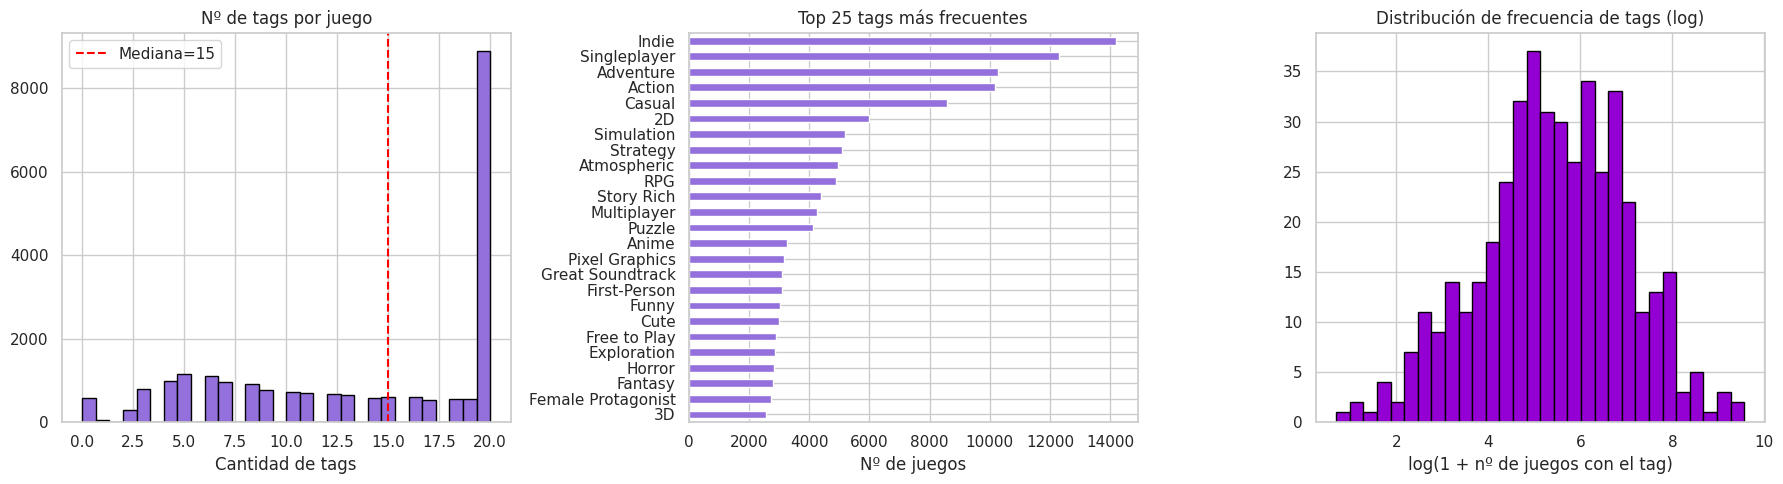


% juegos con 0 tags: 2.5%
% juegos con ≥5 tags: 88.0%


In [ ]:
# Filtrar metadata a juegos activos
meta_active = metadata[metadata['app_id'].isin(active_games)].copy()

# ── Análisis de TAGS ──
# Normalizar campo de tags (puede ser lista o string)
def parse_tags(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            parsed = json.loads(x)
            return parsed if isinstance(parsed, list) else [parsed]
        except:
            return [t.strip() for t in x.split(',') if t.strip()]
    return []

meta_active = meta_active.copy()
meta_active['tags_list'] = meta_active['tags'].apply(parse_tags)
meta_active['n_tags']    = meta_active['tags_list'].apply(len)

all_tags = [tag for tags in meta_active['tags_list'] for tag in tags]
tag_counts = Counter(all_tags)

print(f"Tags únicos en catálogo activo: {len(tag_counts):,}")
print(f"\nDistribución de tags por juego:")
print(meta_active['n_tags'].describe().round(2).to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribución de nº de tags por juego
meta_active['n_tags'].hist(bins=30, ax=axes[0], color='mediumpurple', edgecolor='black')
axes[0].set_title('Nº de tags por juego')
axes[0].set_xlabel('Cantidad de tags')
axes[0].axvline(meta_active['n_tags'].median(), color='red', linestyle='--',
                label=f"Mediana={meta_active['n_tags'].median():.0f}")
axes[0].legend()

# 2. Top 25 tags más frecuentes
top_tags = pd.Series(dict(tag_counts.most_common(25)))
top_tags.sort_values().plot(kind='barh', ax=axes[1], color='mediumpurple')
axes[1].set_title('Top 25 tags más frecuentes')
axes[1].set_xlabel('Nº de juegos')

# 3. Distribución de frecuencia de tags (ley de potencias)
tag_freq = pd.Series(list(tag_counts.values()))
tag_freq.apply(np.log1p).hist(bins=30, ax=axes[2], color='darkviolet', edgecolor='black')
axes[2].set_title('Distribución de frecuencia de tags (log)')
axes[2].set_xlabel('log(1 + nº de juegos con el tag)')

plt.tight_layout()
plt.show()

# Tags con 0 juegos en catálogo activo
print(f"\n% juegos con 0 tags: {(meta_active['n_tags']==0).mean()*100:.1f}%")
print(f"% juegos con ≥5 tags: {(meta_active['n_tags']>=5).mean()*100:.1f}%")

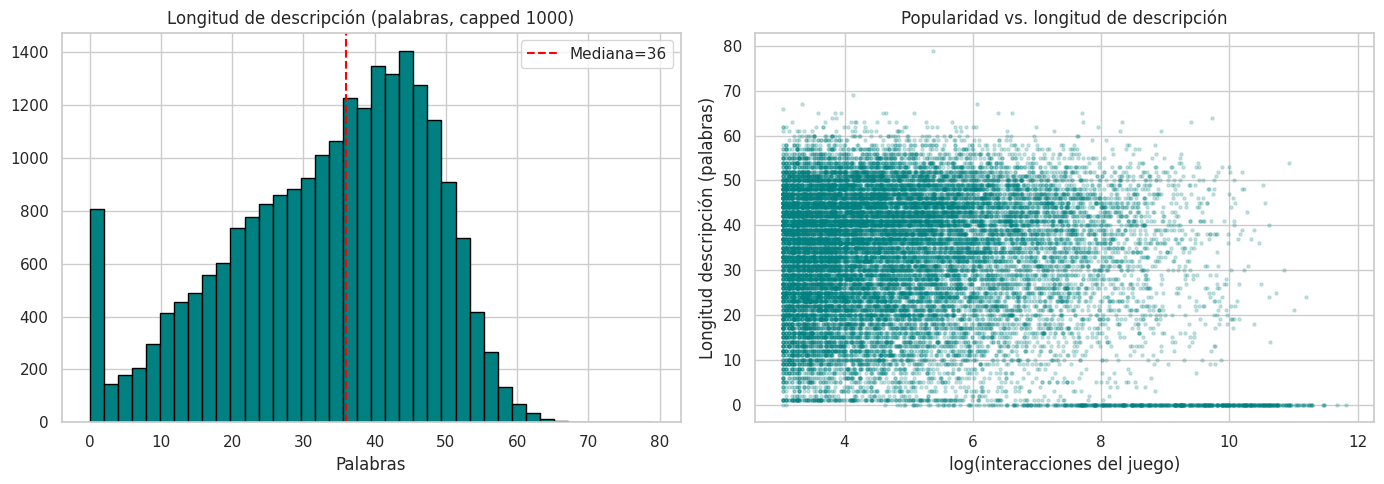

% juegos sin descripción útil (<10 palabras): 8.1%
Mediana longitud descripción: 36 palabras
p25: 24 | p75: 44 palabras


In [ ]:
# ── Análisis de DESCRIPCIONES ──
if 'description' in meta_active.columns:
    meta_active['desc_len'] = meta_active['description'].fillna('').apply(lambda x: len(x.split()))
    meta_active['has_desc'] = meta_active['desc_len'] > 10

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    meta_active['desc_len'].clip(0, 1000).hist(bins=40, ax=axes[0], color='teal', edgecolor='black')
    axes[0].set_title('Longitud de descripción (palabras, capped 1000)')
    axes[0].set_xlabel('Palabras')
    axes[0].axvline(meta_active['desc_len'].median(), color='red', linestyle='--',
                    label=f"Mediana={meta_active['desc_len'].median():.0f}")
    axes[0].legend()

    # Heatmap: popularidad del juego vs. longitud de descripción
    pop_series = recs_filtered.groupby('app_id').size().rename('n_interactions')
    meta_pop = meta_active.set_index('app_id').join(pop_series, how='left')
    meta_pop = meta_pop[meta_pop['n_interactions'].notna()]

    axes[1].scatter(np.log1p(meta_pop['n_interactions']), meta_pop['desc_len'].clip(0,1000),
                    alpha=0.2, s=5, color='teal')
    axes[1].set_xlabel('log(interacciones del juego)')
    axes[1].set_ylabel('Longitud descripción (palabras)')
    axes[1].set_title('Popularidad vs. longitud de descripción')

    plt.tight_layout()
    plt.show()

    print(f"% juegos sin descripción útil (<10 palabras): {(~meta_active['has_desc']).mean()*100:.1f}%")
    print(f"Mediana longitud descripción: {meta_active['desc_len'].median():.0f} palabras")
    print(f"p25: {meta_active['desc_len'].quantile(0.25):.0f} | p75: {meta_active['desc_len'].quantile(0.75):.0f} palabras")
else:
    print("Campo 'description' no encontrado en metadata.")

## 8. Señal combinada y split train/test

### Diseño de la señal de preferencia

Se combinan `is_recommended` y `hours` de la siguiente forma:
- **Señal positiva:** interacciones con `is_recommended=True` son los ítems relevantes.
- **Confianza:** `confidence = log1p(hours)` pondera la intensidad del consumo. Un usuario que jugó 500 horas y recomienda tiene una señal más fuerte que uno que jugó 1 hora.
- **Señal negativa:** las interacciones con `is_recommended=False` se mantienen en el historial para que el modelo no recomiende juegos que el usuario ya rechazó, pero no se usan como ground truth positivo.

### Protocolo de evaluación

- **Split:** leave-one-out temporal por usuario — la interacción **más reciente** de cada usuario es el ítem de test.
- **Ground truth:** un ítem de test es "relevante" solo si `is_recommended=True`.
- **Usuarios evaluados:** aquellos cuya interacción de test es positiva.
- **Métricas:** Precision@10, Recall@10, NDCG@10.

In [ ]:
# Señal combinada
recs_filtered = recs_filtered.copy()
recs_filtered['confidence'] = np.where(
    recs_filtered['is_recommended'],
    np.log1p(recs_filtered['hours'].clip(0)),
    0.0
)

print("Señal de confianza (interacciones positivas):")
conf_pos = recs_filtered[recs_filtered['is_recommended']]['confidence']
print(f"  Mediana: {conf_pos.median():.2f} | Media: {conf_pos.mean():.2f} | Max: {conf_pos.max():.2f}")
print(f"  % con confidence=0 (horas=0 y positivo): {(conf_pos==0).mean()*100:.1f}%")

# ── Submuestra del 10% de usuarios ──
SAMPLE_FRAC = 0.10
RANDOM_STATE = 42

all_users = recs_filtered['user_id'].drop_duplicates()
sample_users = all_users.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE)
recs_baseline = recs_filtered[recs_filtered['user_id'].isin(sample_users)].copy()

print(f"\nSubmuestra ({SAMPLE_FRAC*100:.0f}% de usuarios):")
print(f"  Interacciones: {len(recs_baseline):,}")
print(f"  Usuarios:      {recs_baseline['user_id'].nunique():,}")
print(f"  Juegos:        {recs_baseline['app_id'].nunique():,}")
print(f"  % positivas:   {recs_baseline['is_recommended'].mean()*100:.1f}%")

Señal de confianza (interacciones positivas):
  Mediana: 3.14 | Media: 3.23 | Max: 6.91
  % con confidence=0 (horas=0 y positivo): 0.4%

Submuestra (10% de usuarios):
  Interacciones: 2,226,680
  Usuarios:      190,545
  Juegos:        22,265
  % positivas:   84.8%


In [ ]:
# ── Split train/test temporal ──
# Para cada usuario: la interacción más reciente es test; el resto es train.
recs_baseline = recs_baseline.sort_values(['user_id', 'date'])

# Índice de la última interacción por usuario
last_idx = recs_baseline.groupby('user_id').tail(1).index

train_df = recs_baseline.drop(index=last_idx).reset_index(drop=True)
test_df  = recs_baseline.loc[last_idx].reset_index(drop=True)

# Solo se evalúa en usuarios cuyo ítem de test es positivo
test_pos = test_df[test_df['is_recommended']].copy()
test_neg = test_df[~test_df['is_recommended']].copy()

print(f"Train:                {len(train_df):,} interacciones")
print(f"Test total:           {len(test_df):,} interacciones")
print(f"  Test positivo:      {len(test_pos):,} usuarios evaluables ({len(test_pos)/len(test_df)*100:.1f}%)")
print(f"  Test negativo:      {len(test_neg):,} usuarios excluidos de evaluación")
print(f"\nUsuarios en train con >= 1 interacción: {train_df['user_id'].nunique():,}")

# Diccionarios de acceso rápido
train_items_per_user = train_df.groupby('user_id')['app_id'].apply(set).to_dict()
test_item_per_user   = dict(zip(test_pos['user_id'], test_pos['app_id']))

ALL_ITEMS = set(recs_baseline['app_id'].unique())
print(f"Catálogo completo (submuestra): {len(ALL_ITEMS):,} juegos")

Train:                2,036,135 interacciones
Test total:           190,545 interacciones
  Test positivo:      160,266 usuarios evaluables (84.1%)
  Test negativo:      30,279 usuarios excluidos de evaluación

Usuarios en train con >= 1 interacción: 190,545
Catálogo completo (submuestra): 22,265 juegos


## 9. Modelos de referencia (Baselines)

Se implementan **cuatro baselines** evaluados con el mismo protocolo:
- **Random:** recomienda K juegos al azar del catálogo no visto por el usuario. Sirve como piso mínimo.
- **Most Popular:** recomienda los K juegos con más interacciones positivas en entrenamiento, excluyendo los ya vistos.
- **Content-Based TF-IDF (tags):** perfil del usuario como promedio ponderado por confianza de los vectores TF-IDF de tags. Primer baseline multimodal.
- **ALS (Filtrado Colaborativo):** factorización de matrices con feedback implícito usando la librería . Captura patrones de co-interacción entre usuarios.

Por eficiencia, la evaluación se realiza sobre una muestra aleatoria de **hasta 2.000 usuarios evaluables**.

In [ ]:
# ── Funciones de métricas ──
K = 10

def precision_at_k(recommended, relevant_set, k=K):
    hits = sum(1 for item in recommended[:k] if item in relevant_set)
    return hits / k

def recall_at_k(recommended, relevant_set, k=K):
    hits = sum(1 for item in recommended[:k] if item in relevant_set)
    return hits / len(relevant_set) if relevant_set else 0.0

def ndcg_at_k(recommended, relevant_set, k=K):
    dcg  = sum(1.0 / np.log2(i + 2) for i, item in enumerate(recommended[:k]) if item in relevant_set)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant_set), k)))
    return dcg / idcg if idcg > 0 else 0.0

def evaluate_recommendations(recs_per_user, test_item_per_user, k=K):
    p, r, n = [], [], []
    for user_id, recommended in recs_per_user.items():
        if user_id not in test_item_per_user:
            continue
        relevant = {test_item_per_user[user_id]}
        p.append(precision_at_k(recommended, relevant, k))
        r.append(recall_at_k(recommended, relevant, k))
        n.append(ndcg_at_k(recommended, relevant, k))
    return {
        f'Precision@{k}': np.mean(p),
        f'Recall@{k}':    np.mean(r),
        f'NDCG@{k}':      np.mean(n),
        'n_users':        len(p)
    }

# Muestra de usuarios evaluables (máx 2000 para eficiencia)
eval_users = list(test_item_per_user.keys())
np.random.seed(RANDOM_STATE)
if len(eval_users) > 2000:
    eval_users = list(np.random.choice(eval_users, 2000, replace=False))
print(f"Usuarios evaluables: {len(eval_users):,}")

Usuarios evaluables: 2,000


In [ ]:
# ── Baseline 1: Random ──
rng = np.random.default_rng(RANDOM_STATE)
all_items_list = list(ALL_ITEMS)

recs_random = {}
for user in eval_users:
    seen = train_items_per_user.get(user, set())
    candidates = [i for i in all_items_list if i not in seen]
    if len(candidates) >= K:
        chosen = rng.choice(candidates, size=K, replace=False).tolist()
    else:
        chosen = candidates
    recs_random[user] = chosen

metrics_random = evaluate_recommendations(recs_random, test_item_per_user)
print("Baseline 1 — Random")
for m, v in metrics_random.items():
    print(f"  {m}: {v:.4f}" if isinstance(v, float) else f"  {m}: {v}")

Baseline 1 — Random
  Precision@10: 0.0001
  Recall@10: 0.0010
  NDCG@10: 0.0003
  n_users: 2000


In [ ]:
# ── Baseline 2: Most Popular ──
# Popularidad = nº de interacciones positivas en TRAIN
popularity = (
    train_df[train_df['is_recommended']]
    .groupby('app_id')
    .size()
    .sort_values(ascending=False)
)
popular_list = popularity.index.tolist()

recs_popular = {}
for user in eval_users:
    seen = train_items_per_user.get(user, set())
    recs_popular[user] = [item for item in popular_list if item not in seen][:K]

metrics_popular = evaluate_recommendations(recs_popular, test_item_per_user)
print("Baseline 2 — Most Popular (positivos en train)")
for m, v in metrics_popular.items():
    print(f"  {m}: {v:.4f}" if isinstance(v, float) else f"  {m}: {v}")

Baseline 2 — Most Popular (positivos en train)
  Precision@10: 0.0046
  Recall@10: 0.0455
  NDCG@10: 0.0222
  n_users: 2000


In [ ]:
# ── Baseline 3: Content-Based TF-IDF (tags) ──

# 1. Construir diccionario de tags por juego
tag_dict = {}
for _, row in meta_active.iterrows():
    aid = row['app_id']
    if aid in ALL_ITEMS:
        tag_dict[aid] = ' '.join(row['tags_list']) if row['tags_list'] else ''

# Juegos sin metadata reciben string vacío
for aid in ALL_ITEMS:
    if aid not in tag_dict:
        tag_dict[aid] = ''

item_list = list(ALL_ITEMS)
item_idx  = {aid: i for i, aid in enumerate(item_list)}
corpus    = [tag_dict[aid] for aid in item_list]

# 2. TF-IDF sobre tags
vectorizer = TfidfVectorizer(max_features=3000, min_df=2)
tfidf_matrix = vectorizer.fit_transform(corpus)  # shape: (n_items, vocab)
tfidf_dense  = tfidf_matrix.toarray().astype(np.float32)

n_vocab = tfidf_matrix.shape[1]
n_items_tfidf = tfidf_matrix.shape[0]
print(f"Matriz TF-IDF: {n_items_tfidf:,} juegos × {n_vocab:,} features")

# 3. Calcular perfil de usuario y recomendar
train_pos = train_df[train_df['is_recommended']].copy()

recs_cb = {}
no_profile = 0

for user in eval_users:
    seen = train_items_per_user.get(user, set())

    # Historial positivo del usuario con confidence
    hist = train_pos[train_pos['user_id'] == user]
    valid = hist[hist['app_id'].isin(item_idx)]

    if len(valid) == 0:
        # Sin historial positivo con metadata → usar Most Popular como fallback
        recs_cb[user] = [item for item in popular_list if item not in seen][:K]
        no_profile += 1
        continue

    idxs    = [item_idx[aid] for aid in valid['app_id']]
    weights = valid['confidence'].values.astype(np.float32)
    weights = np.where(weights == 0, 1e-6, weights)  # evitar división por 0
    weights = weights / weights.sum()

    # Perfil de usuario: promedio ponderado de vectores TF-IDF
    user_profile = weights @ tfidf_dense[idxs]  # shape: (vocab,)

    # Similitud coseno con todos los juegos
    norms = np.linalg.norm(tfidf_dense, axis=1) + 1e-10
    user_norm = np.linalg.norm(user_profile) + 1e-10
    scores = (tfidf_dense @ user_profile) / (norms * user_norm)

    # Excluir ítems vistos
    for s in seen:
        if s in item_idx:
            scores[item_idx[s]] = -np.inf

    top_idxs = np.argsort(scores)[::-1][:K]
    recs_cb[user] = [item_list[i] for i in top_idxs]

metrics_cb = evaluate_recommendations(recs_cb, test_item_per_user)
print(f"Baseline 3 — Content-Based TF-IDF (tags)")
print(f"  (usuarios sin historial positivo → fallback Most Popular: {no_profile})")
for m, v in metrics_cb.items():
    print(f"  {m}: {v:.4f}" if isinstance(v, float) else f"  {m}: {v}")

Matriz TF-IDF: 22,265 juegos × 480 features
Baseline 3 — Content-Based TF-IDF (tags)
  (usuarios sin historial positivo → fallback Most Popular: 2)
  Precision@10: 0.0015
  Recall@10: 0.0145
  NDCG@10: 0.0083
  n_users: 2000


In [ ]:
# ── Baseline 4: ALS (Filtrado Colaborativo, Implicit Feedback) ──

# 1. Mapeo de IDs a índices enteros
all_users_list_als = sorted(recs_baseline['user_id'].unique())
all_items_list_als = sorted(recs_baseline['app_id'].unique())
user_to_idx = {u: i for i, u in enumerate(all_users_list_als)}
item_to_idx_als = {a: i for i, a in enumerate(all_items_list_als)}

# 2. Matriz user x item con confianza (solo interacciones positivas de train)
ALPHA = 40
train_pos_als = train_df[train_df['is_recommended']].copy()
train_pos_als = train_pos_als[
    train_pos_als['user_id'].isin(user_to_idx) &
    train_pos_als['app_id'].isin(item_to_idx_als)
]

rows_als = train_pos_als['user_id'].map(user_to_idx).values.astype(int)
cols_als = train_pos_als['app_id'].map(item_to_idx_als).values.astype(int)
data_als = (1.0 + ALPHA * train_pos_als['confidence'].values).astype('float32')

user_item = csr_matrix(
    (data_als, (rows_als, cols_als)),
    shape=(len(all_users_list_als), len(all_items_list_als))
)

# 3. Entrenar ALS (implicit espera matriz item x user)
model_als = implicit.als.AlternatingLeastSquares(
    factors=64, regularization=0.1, iterations=15,
    calculate_training_loss=True, random_state=RANDOM_STATE
)
model_als.fit(user_item)
print(f"ALS entrenado: {model_als.factors} factores latentes")

# 4. Generar recomendaciones para eval_users
recs_als = {}
cold_start_als = 0

for user in eval_users:
    seen = train_items_per_user.get(user, set())
    if user not in user_to_idx:
        recs_als[user] = [item for item in popular_list if item not in seen][:K]
        cold_start_als += 1
        continue
    uid = user_to_idx[user]
    ids, _ = model_als.recommend(
        uid, user_item[uid], N=K, filter_already_liked_items=True
    )
    recs_als[user] = [all_items_list_als[i] for i in ids]

metrics_als = evaluate_recommendations(recs_als, test_item_per_user)
print(f"Baseline 4 — ALS (Filtrado Colaborativo)")
print(f"  (cold-start sin historial -> fallback MostPop: {cold_start_als})")
for m, v in metrics_als.items():
    print(f"  {m}: {v:.4f}" if isinstance(v, float) else f"  {m}: {v}")

  0%|          | 0/15 [00:00<?, ?it/s]

ALS entrenado: 64 factores latentes
Baseline 4 — ALS (Filtrado Colaborativo)
  (cold-start sin historial -> fallback MostPop: 0)
  Precision@10: 0.0077
  Recall@10: 0.0765
  NDCG@10: 0.0381
  n_users: 2000


## 10. Comparación de resultados

,Precision@10,Recall@10,NDCG@10
Random,0.0001,0.0010,0.0003
Most Popular,0.0046,0.0455,0.0222
CB-TF-IDF (tags),0.0015,0.0145,0.0083
ALS (Colaborativo),0.0076,0.0765,0.0381


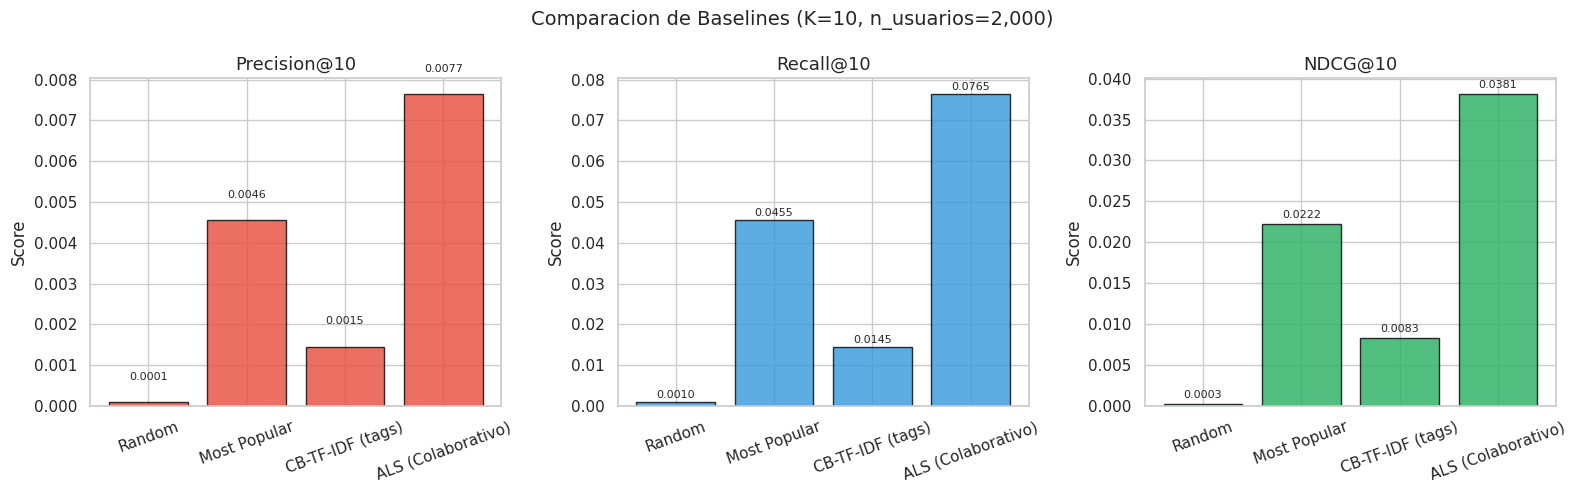

Mejoras de NDCG@10 relativas a Most Popular:
  Random                : 0.0003  (-98.7% vs MostPop)
  Most Popular          : 0.0222  (+0.0% vs MostPop)
  CB-TF-IDF (tags)      : 0.0083  (-62.8% vs MostPop)
  ALS (Colaborativo)    : 0.0381  (+71.8% vs MostPop)


In [ ]:
results = {
    'Random':             metrics_random,
    'Most Popular':       metrics_popular,
    'CB-TF-IDF (tags)':  metrics_cb,
    'ALS (Colaborativo)': metrics_als,
}

results_df = pd.DataFrame(results).T.drop(columns=['n_users'])
results_df = results_df.astype(float)
display(results_df.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#E74C3C', '#3498DB', '#27AE60', '#8E44AD']
metrics_cols = [f'Precision@{K}', f'Recall@{K}', f'NDCG@{K}']

for ax, metric, color in zip(axes, metrics_cols, colors):
    vals = results_df[metric]
    bars = ax.bar(vals.index, vals.values, color=color, alpha=0.8, edgecolor='black')
    ax.set_title(metric, fontsize=13)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)

plt.suptitle(f'Comparacion de Baselines (K={K}, n_usuarios={len(eval_users):,})', fontsize=14)
plt.tight_layout()
plt.show()

# Mejoras relativas sobre Most Popular (baseline fuerte)
print('Mejoras de NDCG@10 relativas a Most Popular:')
base_ndcg = metrics_popular[f'NDCG@{K}']
for name, m in results.items():
    delta = (m[f'NDCG@{K}'] / max(base_ndcg, 1e-9) - 1) * 100
    print(f'  {name:<22}: {m[f"NDCG@{K}"]:.4f}  ({delta:+.1f}% vs MostPop)')
